# Fraud Detection — Model Training

Orchestrates the full pipeline:
`load → feature engineering → prep → split → SHAP selection → tune → train → evaluate → save`

All logic lives in `src/features.py`, `src/model.py`, and `src/ensemble.py`.
This notebook is for running and observing, not for defining functions.

In [1]:
import sys
sys.path.append('..')

import yaml
import mlflow
import mlflow.lightgbm
from pathlib import Path

import numpy as np
import pandas as pd

from src.features import (
    build_features,
    fit_freq_encoders, apply_freq_encoders,
)
from src.model import (
    prepare_features,
    two_way_split,
    select_features_shap,
    LABEL,
)
from src.ensemble import (
    encode_for_ensemble,
    tune_all,
    train_ensemble,
    generate_oof_predictions,
    train_meta_learner,
    evaluate_ensemble,
    predict_stack,
    tune_threshold,
    save_ensemble,
)

DATA_DIR = '../data'
import src as _src
MLRUNS = str(Path(_src.__file__).parent.parent / 'mlruns')
mlflow.set_tracking_uri(MLRUNS)
mlflow.set_experiment('fraud-detection')

<Experiment: artifact_location='file:///Users/sonje/Desktop/Rohit/Old%20Desktop/Python/fraud-detection/mlruns/406551328193655437', creation_time=1779566767740, experiment_id='406551328193655437', last_update_time=1779566767740, lifecycle_stage='active', name='fraud-detection', tags={}>

In [2]:
with open('../config.yaml') as f:
    cfg = yaml.safe_load(f)

RANDOM_STATE = cfg['random_state']
np.random.seed(RANDOM_STATE)
print(f"RANDOM_STATE = {RANDOM_STATE}")

RANDOM_STATE = 42


In [3]:
QUICK_TEST  = cfg['tuning']['quick_test']
n_trials    = cfg['tuning']['n_trials_quick'] if QUICK_TEST else cfg['tuning']['n_trials']
shap_sample = 5_000                          if QUICK_TEST else cfg['feature_selection']['sample_size']

print(f'QUICK_TEST  = {QUICK_TEST}')
print(f'  n_trials    = {n_trials}')
print(f'  shap_sample = {shap_sample:,}')

QUICK_TEST  = False
  n_trials    = 50
  shap_sample = 100,000


## 1. Load raw data

In [4]:
trn = pd.read_csv(f'{DATA_DIR}/train_transaction.csv')
idn = pd.read_csv(f'{DATA_DIR}/train_identity.csv')
print(f'Transactions : {trn.shape}')
print(f'Identity     : {idn.shape}')

Transactions : (590540, 394)
Identity     : (144233, 41)


## 2. Feature engineering

In [5]:
df = build_features(trn, idn)
print(f'After feature engineering: {df.shape}')

Merged            : 590,540 rows × 434 cols
Identity coverage : 24.4%
Dropped 11 weak id columns


/Users/sonje/Desktop/Rohit/Old Desktop/Python/fraud-detection/.venv/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/sonje/Desktop/Rohit/Old Desktop/Python/fraud-detection/.venv/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/sonje/Desktop/Rohit/Old Desktop/Python/fraud-detection/.venv/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


After feature engineering: (590540, 485)


## 3. Prepare feature matrix

In [6]:
df = prepare_features(df)
print(f'After prep: {df.shape}')

Dropping 9 columns with >99% missing
Dropping 0 constant columns
After prep: (590540, 474)


## 4. Chronological split

| Split | Fraction | Purpose |
|---|---|---|
| **train** | 80% | Model training + Optuna tuning |
| **test**  | 20% | Early stopping + final evaluation |

In [7]:
train_df, test_df = two_way_split(
    df,
    train_frac=cfg['split']['train_frac'],
)

FEATURES = [c for c in train_df.columns if c != LABEL]
X_train, y_train = train_df[FEATURES], train_df[LABEL]
X_test,  y_test  = test_df[FEATURES],  test_df[LABEL]

print(f'Train : {X_train.shape}  |  fraud rate: {y_train.mean():.2%}')
print(f'Test  : {X_test.shape}   |  fraud rate: {y_test.mean():.2%}')

# Persist engineered test set for the streaming simulation notebook
test_df.to_parquet('../data/test_features.parquet', index=False)
print(f"Saved {len(test_df):,} rows → data/test_features.parquet")

Train : (472432, 473)  |  fraud rate: 3.51%
Test  : (118108, 473)   |  fraud rate: 3.44%
Saved 118,108 rows → data/test_features.parquet


## 5. Frequency encoding

Fit on **train only** — applied to test using training-set counts to prevent leakage.

| Encoder | New features | Signal |
|---------|-------------|--------|
| **Frequency** | `card1_freq`, `uid_freq`, `P_emaildomain_freq`, `addr1_freq`, `DeviceInfo_freq` | Rare entities → suspicious |

`uid` is dropped after encoding — `uid_freq` carries its signal without the high-cardinality problem.

In [8]:
# ── Frequency encoding ─────────────────────────────────────────────────────────
freq_encoders = fit_freq_encoders(X_train)
X_train = apply_freq_encoders(X_train, freq_encoders)
X_test  = apply_freq_encoders(X_test,  freq_encoders)


# Drop raw uid — uid_freq carries its signal without high-cardinality problems
for _df in [X_train, X_test]:
    _df.drop(columns=["uid"], inplace=True, errors="ignore")

freq_cols  = [c for c in X_train.columns if c.endswith("_freq")]
dt_cols    = [c for c in X_train.columns if c.startswith("dt_")]
d_agg_cols = [c for c in X_train.columns if "_D" in c and (c.endswith("_mean") or c.endswith("_std"))]
print(f"Freq features      ({len(freq_cols)}) : {freq_cols}")
print(f"Time-delta features({len(dt_cols)}) : {dt_cols}")
print(f"D-agg features     ({len(d_agg_cols)}): {d_agg_cols[:4]}...")
print(f"Feature matrix     : {X_train.shape}")

Freq features      (5) : ['card1_freq', 'uid_freq', 'P_emaildomain_freq', 'addr1_freq', 'DeviceInfo_freq']
Time-delta features(2) : ['dt_card1_last', 'dt_uid_last']
D-agg features     (18): ['uid_D1_mean', 'uid_D1_std', 'uid_D2_mean', 'uid_D2_std']...
Feature matrix     : (472432, 477)


## 6. Feature selection

Uses SHAP (TreeExplainer) on a 100K subsample to rank features by mean absolute
contribution, then keeps the top 100. Results are cached to `models/shap_features.json`
so SHAP only runs once — subsequent runs load from cache instantly.

In [9]:
X_train_f, X_test_f, features_f = select_features_shap(
    X_train, y_train, X_test,
    top_n=cfg['feature_selection']['top_n'],
    sample_size=shap_sample,
    force_recompute=True,   # recompute — feature set changed with freq/target/time-delta features
)
print(f"\nSelected {len(features_f)} features from {X_train.shape[1]} total")

Computing SHAP on 100,000 rows × 477 features ...


/Users/sonje/Desktop/Rohit/Old Desktop/Python/fraud-detection/.venv/lib/python3.9/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


SHAP selection : top 100 / 477 features
Top 10 by mean |SHAP|:
  TransactionAmt                      0.2507
  P_emaildomain                       0.2138
  C14                                 0.1805
  card6                               0.1796
  V91                                 0.1627
  C13                                 0.1609
  C1                                  0.1516
  TransactionDT                       0.1498
  card1                               0.1343
  D3                                  0.1326
SHAP features cached to shap_features.json

Selected 100 features from 477 total


## 7. Stacking ensemble (LightGBM + XGBoost, meta: XGBoost)

Base models tuned independently with Optuna, then blended by a shallow
XGBoost meta-learner trained on out-of-fold predictions.

### 7a. Encode categoricals

Ordinal-encodes category columns to integers. Fit on `X_train_f` so codes are
consistent across train and test splits.

In [10]:
X_train_enc, X_test_enc, cat_cols, cat_encoders = encode_for_ensemble(X_train_f, X_test_f)

print(f"Encoded {len(cat_cols)} categorical columns: {cat_cols}")

Encoded 13 categorical columns: ['P_emaildomain', 'card6', 'id_31', 'M6', 'ProductCD', 'id_33', 'R_emaildomain', 'DeviceInfo', 'M5', 'M3', 'M4', 'card4', 'M7']


### 7b. Tune base models

LightGBM and XGBoost tuned independently with Optuna.
`scale_pos_weight` is fixed from the class ratio — not searched.

In [11]:
all_best_params = tune_all(
    X_train_enc, y_train, cat_cols,
    n_trials=n_trials,   # 3 (QUICK_TEST) or 50 (full run)
)

print("\nBest params per model:")
for name, params in all_best_params.items():
    print(f"  {name}: {params}")

Tuning LightGBM  (50 trials) ...


  0%|          | 0/50 [00:00<?, ?it/s]

  LightGBM best PR-AUC : 0.5703  {'n_estimators': 478, 'max_depth': 11, 'learning_rate': 0.04937820131347326, 'bagging_fraction': 0.6201951346223865, 'feature_fraction': 0.9522457264033608}

Tuning XGBoost   (50 trials) ...


  0%|          | 0/50 [00:00<?, ?it/s]

  XGBoost  best PR-AUC : 0.6157  {'n_estimators': 463, 'max_depth': 12, 'learning_rate': 0.10676105860754179, 'subsample': 0.8789769619088554, 'colsample_bytree': 0.7342566588938357}

Best params per model:
  lgbm: {'n_estimators': 478, 'max_depth': 11, 'learning_rate': 0.04937820131347326, 'bagging_fraction': 0.6201951346223865, 'feature_fraction': 0.9522457264033608}
  xgb: {'n_estimators': 463, 'max_depth': 12, 'learning_rate': 0.10676105860754179, 'subsample': 0.8789769619088554, 'colsample_bytree': 0.7342566588938357}


### 7c. Train, evaluate, and save ensemble

scale_pos_weight: 27.5  (neg=455,833, pos=16,599)

Training LightGBM ...
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
  Trained 478 trees

Training XGBoost ...
Ensem

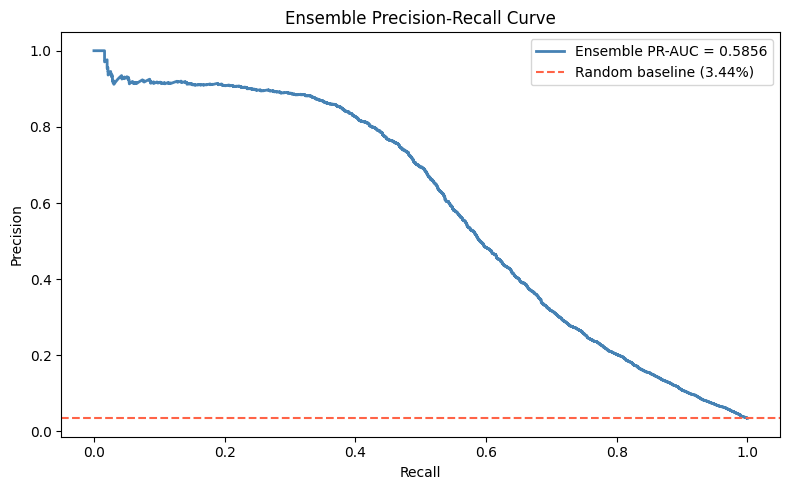

In [12]:
ensemble_models = train_ensemble(
    X_train_enc, y_train,
    X_test_enc,  y_test,
    best_params=all_best_params,
    cat_cols=cat_cols,
)

ensemble_metrics = evaluate_ensemble(
    ensemble_models, X_test_enc, y_test,
    threshold=cfg['ensemble']['threshold'],
    plot=True,
)

### 7d. Stacking — OOF predictions + XGBoost meta-learner

Generate out-of-fold predictions from both base models using `TimeSeriesSplit`,
then train a shallow XGBoost meta-learner to blend them.

The first ~1/(n_splits+1) ≈ 17% of rows only appear in training folds and are
excluded from OOF — the meta-learner trains on the remaining ~83%.

Generating OOF predictions for meta-learner ...
  OOF fold 1/5 ...
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
  OOF fold 2/5 ...
[LightGBM] [Warning] Met negative 

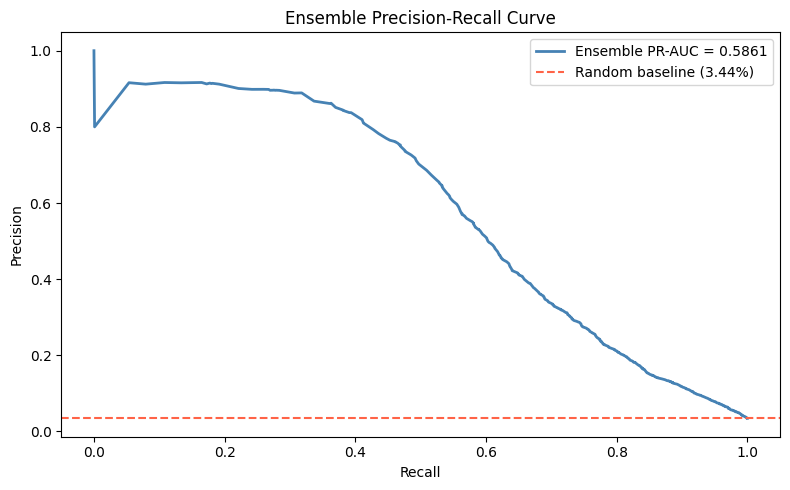


Stack PR-AUC  : 0.5861
Soft-vote PR-AUC: 0.5856


In [13]:
print('Generating OOF predictions for meta-learner ...')
oof_df, y_oof = generate_oof_predictions(
    all_best_params, X_train_enc, y_train, cat_cols,
    n_splits=cfg['tuning']['n_cv_splits'],
)

meta_learner = train_meta_learner(oof_df, y_oof)

# Evaluate stacked model on test set (before calibration)
stack_metrics = evaluate_ensemble(
    ensemble_models, X_test_enc, y_test,
    threshold=cfg['ensemble']['threshold'],
    plot=True,
    meta_learner=meta_learner,
)
print(f'\nStack PR-AUC  : {stack_metrics["pr_auc"]:.4f}')
print(f'Soft-vote PR-AUC: {ensemble_metrics["pr_auc"]:.4f}')

### 7e. Threshold tuning

Find the decision threshold that maximises F-beta on the **test set** using stacked probabilities.
β=2 weights recall 4× over precision — missing fraud costs more than a false alarm.

Optimal threshold (F2) : 0.1413
  Precision : 0.4075
  Recall    : 0.6555
  F2       : 0.5844


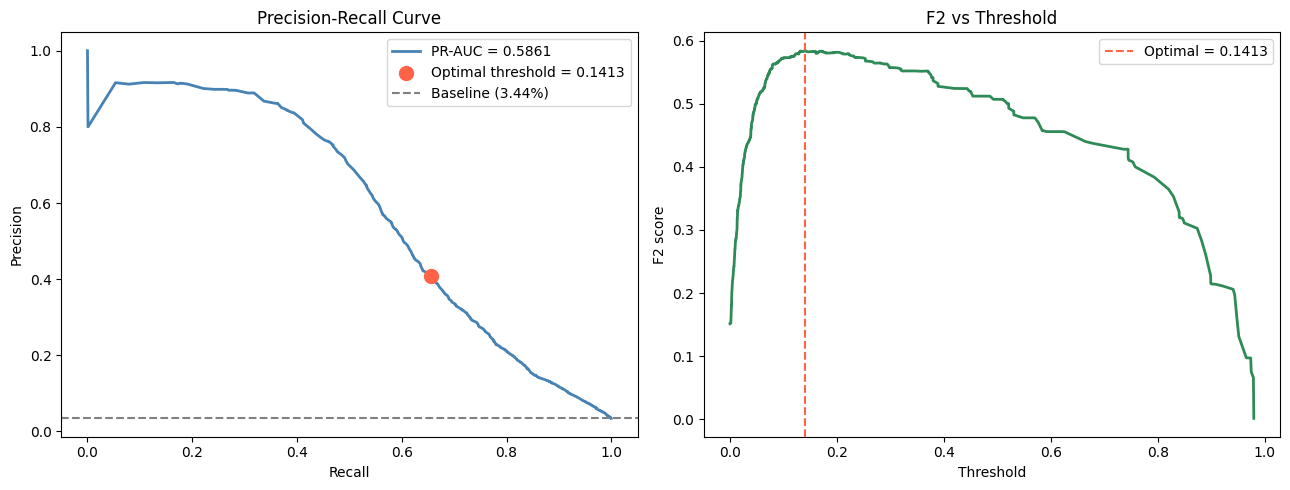

In [14]:
probs_test = predict_stack(ensemble_models, meta_learner, X_test_enc)
best = tune_threshold(y_test, probs_test, beta=cfg['threshold']['beta'])

In [15]:
# Save ensemble with meta_learner + optimal threshold
save_ensemble(
    ensemble_models, cat_cols, cat_encoders,
    calibrator=None,
    threshold=best['threshold'],
    meta_learner=meta_learner,
)

print(f'\nFinal model saved.')
print(f"  Ensemble  : stacking (meta XGBoost)")
print(f"  Threshold : {best['threshold']:.4f}  (F{cfg['threshold']['beta']:.0f}-optimal)")

Ensemble saved to /Users/sonje/Desktop/Rohit/Old Desktop/Python/fraud-detection/notebooks/../models/ensemble_fraud.pkl  (2 models, stacking, threshold=0.1413)

Final model saved.
  Ensemble  : stacking (meta XGBoost)
  Threshold : 0.1413  (F2-optimal)


## 8. MLflow logging

Logs all params, metrics, and artefact paths in one place so every run is
fully reproducible from the MLflow UI without hunting through individual cells.

In [16]:
beta = cfg['threshold']['beta']

with mlflow.start_run(run_name='ensemble-stacking'):

    # ── Params ────────────────────────────────────────────────────────────────
    mlflow.log_params({
        'train_rows':          len(X_train_enc),
        'test_rows':           len(X_test_enc),
        'n_features':          X_train_enc.shape[1],
        'fraud_rate_train':    round(float(y_train.mean()), 4),
        'fraud_rate_test':     round(float(y_test.mean()), 4),
        'feature_selection':   'SHAP top 100',
        'ensemble':            'stack_lgbm_xgb_meta_xgb',
        'threshold_beta':      beta,
    })
    for model_name, params in all_best_params.items():
        mlflow.log_params({f"{model_name}__{k}": v for k, v in params.items()})

    # ── Metrics ───────────────────────────────────────────────────────────────
    mlflow.log_metrics({
        'pr_auc_soft_vote':          ensemble_metrics['pr_auc'],
        'pr_auc_stack':              stack_metrics['pr_auc'],
        'roc_auc':                   stack_metrics['roc_auc'],
        'optimal_threshold':         best['threshold'],
        'precision_at_threshold':    best['precision'],
        'recall_at_threshold':       best['recall'],
        f'f{beta:.0f}_at_threshold': best['f_beta'],
    })

    # ── Artefact ──────────────────────────────────────────────────────────────
    mlflow.log_artifact('../' + cfg['paths']['ensemble'])

    print(f'MLflow run logged.')
    print(f"  Soft-vote PR-AUC : {ensemble_metrics['pr_auc']:.4f}")
    print(f"  Stack PR-AUC     : {stack_metrics['pr_auc']:.4f}")
    print(f"  Threshold (F{beta:.0f})   : {best['threshold']:.4f}  |  P={best['precision']:.3f}  R={best['recall']:.3f}")

MLflow run logged.
  Soft-vote PR-AUC : 0.5856
  Stack PR-AUC     : 0.5861
  Threshold (F2)   : 0.1413  |  P=0.408  R=0.656


## 9. View MLflow UI

```bash
mlflow ui
```
Open http://localhost:5000 to compare all runs side by side.